In [1]:
from dataloader_mapillary import *
from dataloader_cityscapes2 import *
import cv2 as cv
import matplotlib.pyplot as plt
import random
import sys
from pathlib import Path
from torch.utils.data import *
import torchvision
#from PIL import *
import PIL.Image as Image
sys.path.insert(1, '../mapillary')
from MapillaryIntendedObjs import *

In [2]:
mapil = MapillaryLoader()

In [3]:
first = mapil[31]

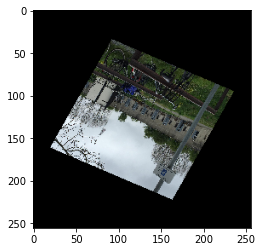

In [4]:
plt.imshow(first["image"].permute(1, 2, 0))
plt.show()

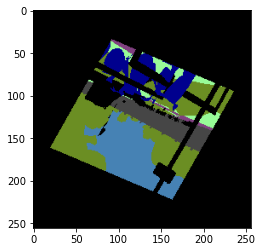

In [5]:
plt.imshow(first["seg"].permute(1, 2, 0))
plt.show()

In [6]:
first["label"][:,0,0]

tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=torch.float64)

In [7]:
city = CityscapesLoader()

In [8]:
first_city = city[21]

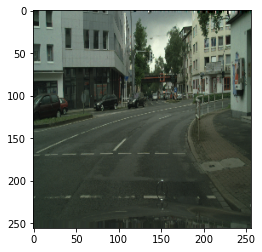

In [9]:
plt.imshow(first_city["image"].permute(1, 2, 0))
plt.show()

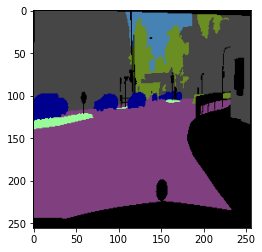

In [10]:
plt.imshow(first_city["seg"].permute(1, 2, 0))
plt.show()

In [11]:
first_city["label"][:,150,150]

tensor([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=torch.float64)

In [12]:
dataset = ConcatDataset([CityscapesLoader(), MapillaryLoader()])

In [13]:
train_loader = DataLoader(dataset = dataset, batch_size = 2, shuffle = True, drop_last = True)

In [14]:
for batch in train_loader:
    break

In [15]:
batch.keys()

dict_keys(['image', 'label', 'seg'])

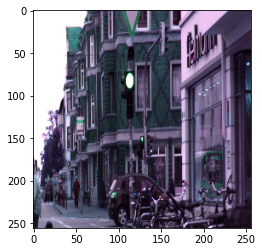

In [16]:
plt.imshow(batch["image"][0].permute(1, 2, 0))
plt.show()

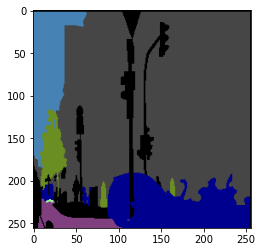

In [17]:
plt.imshow(batch["seg"][0].permute(1, 2, 0))
plt.show()

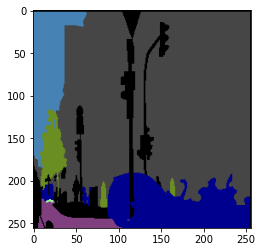

In [40]:
plt.imshow((x[0]/255).permute(1, 2, 0))
plt.show()

In [18]:
batch["label"][0].shape

torch.Size([10, 256, 256])

In [35]:
def return_color(idx):
    return tuple(classIds[list(classIds.keys())[int(idx)]])


def prMask_to_color(img):
    pixel_to_color = np.vectorize(return_color)
    argmax = torch.argmax(img, dim = 1)
    resu = pixel_to_color(argmax)
    return torch.tensor(np.transpose(np.stack((resu[0],resu[1], resu[2])), (1,0,2,3))).float()

In [36]:
x = prMask_to_color(batch["label"])

In [37]:
x.shape

torch.Size([2, 3, 256, 256])